Branch 4 — Rates & Curves
Date range : 1989-12-29 -> 2026-03-13

Indicator                Days         Start   Current      Mean       Min       Max
--------------------------------------------------------------------------------
  US 2Y                 10285    1990-01-02      3.74      3.35      0.10      9.03
  US 5Y                 10285    1990-01-02      3.87      3.87      0.19      9.07
  US 10Y                10285    1990-01-02      4.26      4.35      0.51      9.06
  US 30Y                10285    1990-01-02      4.88      4.86      1.00      9.17
  Germany 2Y            10060    1990-09-18      2.42      2.69     -1.00      9.35
  Germany 5Y            10057    1990-08-07      2.61      3.06     -0.99      9.14
  Germany 10Y           10283    1990-01-02      2.96      3.67     -0.86      9.13
  Germany 30Y            9031    1994-01-03      3.52      3.66     -0.49      8.14
  UK 2Y                  9657    1992-01-02      4.09      3.62     -0.16     10.55
  UK 5Y       

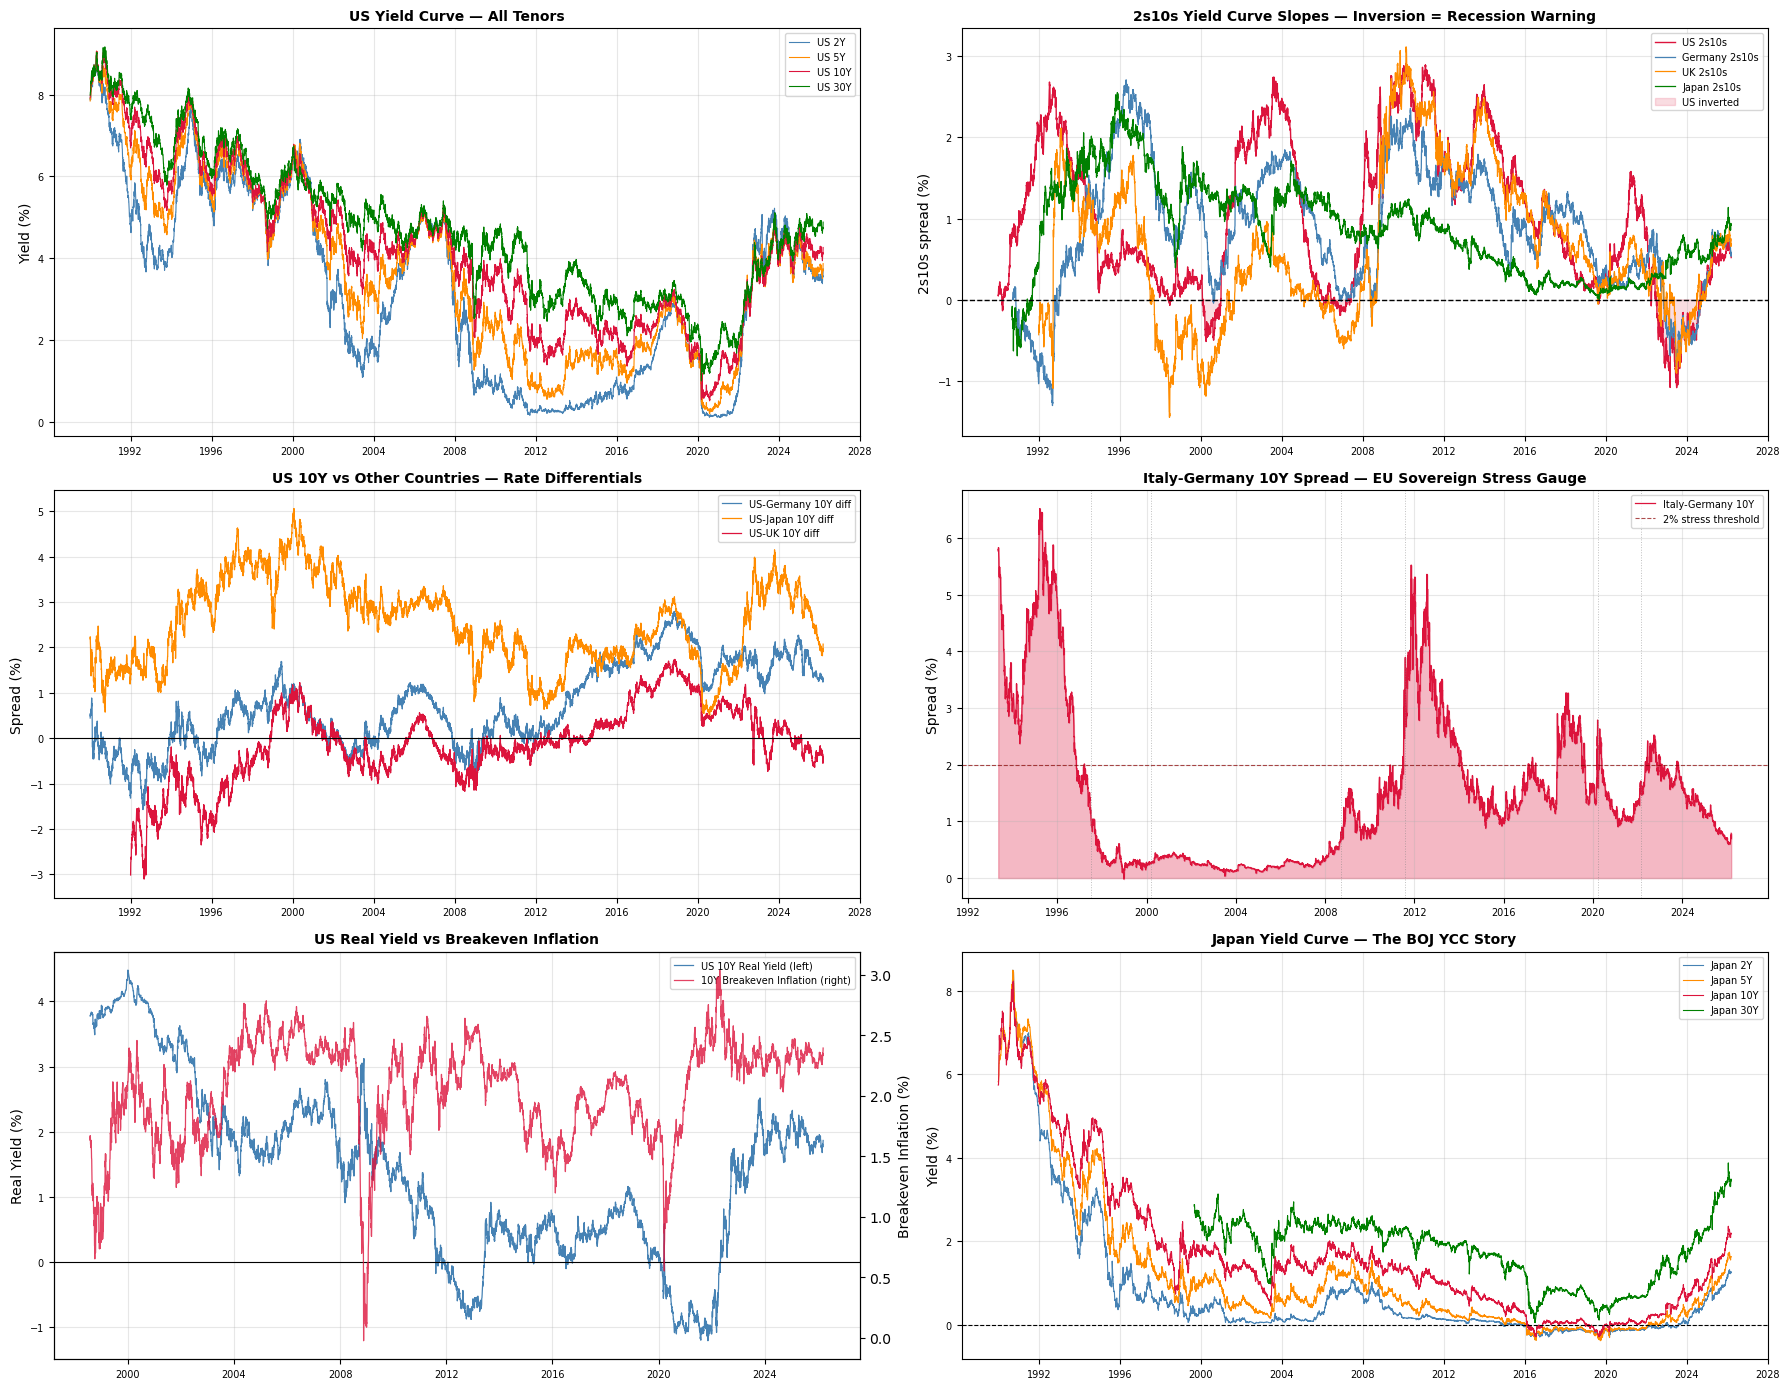


Chart saved: C:\Users\sarda\Desktop\GlobalMacroPulse\outputs\charts\05_branch4_rates_overview.png


In [1]:
import sys, os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import warnings
warnings.filterwarnings('ignore')

PROJECT_ROOT = r"C:\Users\sarda\Desktop\GlobalMacroPulse"
sys.path.insert(0, os.path.join(PROJECT_ROOT, "config"))
import settings as cfg

# ── Load prices (rates are levels, not returns) ───────────────────────────────
prices = pd.read_csv(cfg.ALIGNED_PRICES_FILE, index_col="date", parse_dates=True)

# ── Define rates universe ─────────────────────────────────────────────────────
US_CURVE = {
    "USGG2YR Index":  "US 2Y",
    "USGG5YR Index":  "US 5Y",
    "USGG10YR Index": "US 10Y",
    "USGG30YR Index": "US 30Y",
}

DE_CURVE = {
    "GDBR2 Index":  "Germany 2Y",
    "GDBR5 Index":  "Germany 5Y",
    "GDBR10 Index": "Germany 10Y",
    "GDBR30 Index": "Germany 30Y",
}

UK_CURVE = {
    "GUKG2 Index":  "UK 2Y",
    "GUKG5 Index":  "UK 5Y",
    "GUKG10 Index": "UK 10Y",
    "GUKG30 Index": "UK 30Y",
}

JP_CURVE = {
    "GJGB2 Index":  "Japan 2Y",
    "GJGB5 Index":  "Japan 5Y",
    "GJGB10 Index": "Japan 10Y",
    "GJGB30 Index": "Japan 30Y",
}

OTHER_RATES = {
    "GBTPGR10 Index": "Italy 10Y",
    "GFRN10 Index":   "France 10Y",
    "GSWISS10 Index": "Switzerland 10Y",
    "GACGB10 Index":  "Australia 10Y",
    "GCAN10YR Index": "Canada 10Y",
    "GIND10YR Index": "India 10Y",
    "GCNY10YR Index": "China 10Y",
}

REAL_RATES = {
    "USGGBE10 Index": "US 10Y Breakeven",
    "USGGBE05 Index": "US 5Y Breakeven",
}

ALL_RATES = {**US_CURVE, **DE_CURVE, **UK_CURVE, **JP_CURVE,
             **OTHER_RATES, **REAL_RATES}

# ── Extract rate levels ───────────────────────────────────────────────────────
rates = prices[list(ALL_RATES.keys())].copy()
rates.dropna(how="all", inplace=True)

print("Branch 4 — Rates & Curves")
print("="*65)
print(f"Date range : {rates.dropna(how='all').index.min().date()} -> "
      f"{rates.dropna(how='all').index.max().date()}")
print()
print(f"{'Indicator':<22} {'Days':>6}  {'Start':>12}  "
      f"{'Current':>8}  {'Mean':>8}  {'Min':>8}  {'Max':>8}")
print("-"*80)
for ticker, name in ALL_RATES.items():
    s = rates[ticker].dropna()
    if not s.empty:
        print(f"  {name:<20} {len(s):>6}  "
              f"{str(s.index.min().date()):>12}  "
              f"{s.iloc[-1]:>8.2f}  "
              f"{s.mean():>8.2f}  "
              f"{s.min():>8.2f}  "
              f"{s.max():>8.2f}")


# ── Compute yield curve spreads ───────────────────────────────────────────────
# These are the most watched recession and cycle indicators

# 2s10s: the single most important recession indicator
us_2s10s = prices["USGG10YR Index"] - prices["USGG2YR Index"]
de_2s10s = prices["GDBR10 Index"]   - prices["GDBR2 Index"]
uk_2s10s = prices["GUKG10 Index"]   - prices["GUKG2 Index"]
jp_2s10s = prices["GJGB10 Index"]   - prices["GJGB2 Index"]

us_2s10s.name = "US 2s10s"
de_2s10s.name = "Germany 2s10s"
uk_2s10s.name = "UK 2s10s"
jp_2s10s.name = "Japan 2s10s"

# 5s30s: long end steepness / inflation expectations
us_5s30s = prices["USGG30YR Index"] - prices["USGG5YR Index"]
us_5s30s.name = "US 5s30s"

# Cross-country 10Y differentials (key for FX prediction)
us_de_10y  = prices["USGG10YR Index"] - prices["GDBR10 Index"]
us_jp_10y  = prices["USGG10YR Index"] - prices["GJGB10 Index"]
us_uk_10y  = prices["USGG10YR Index"] - prices["GUKG10 Index"]
it_de_10y  = prices["GBTPGR10 Index"] - prices["GDBR10 Index"]  # EU stress

us_de_10y.name  = "US-Germany 10Y diff"
us_jp_10y.name  = "US-Japan 10Y diff"
us_uk_10y.name  = "US-UK 10Y diff"
it_de_10y.name  = "Italy-Germany 10Y diff"

# Real yield proxy: US 10Y nominal minus 10Y breakeven
us_real_10y = prices["USGG10YR Index"] - prices["USGGBE10 Index"]
us_real_10y.name = "US 10Y Real Yield"

print(f"\nYield Curve Spreads (current):")
print("-"*50)
for spread in [us_2s10s, de_2s10s, uk_2s10s, jp_2s10s, us_5s30s]:
    cur = spread.dropna().iloc[-1]
    mean = spread.dropna().mean()
    inv  = "INVERTED" if cur < 0 else "normal"
    print(f"  {spread.name:<22} {cur:>+6.2f}%  "
          f"(mean: {mean:>+.2f}%)  [{inv}]")

print(f"\nCross-Country 10Y Differentials (current):")
print("-"*50)
for diff in [us_de_10y, us_jp_10y, us_uk_10y, it_de_10y]:
    cur  = diff.dropna().iloc[-1]
    mean = diff.dropna().mean()
    print(f"  {diff.name:<26} {cur:>+6.2f}%  (mean: {mean:>+.2f}%)")

print(f"\n  US 10Y Real Yield: {us_real_10y.dropna().iloc[-1]:>+.2f}%  "
      f"(mean: {us_real_10y.dropna().mean():>+.2f}%)")


# ── Plot yield curves and spreads ─────────────────────────────────────────────
CRISES = [
    ("1997-07-02","Asia"),("2000-03-10","Dot-com"),
    ("2008-09-15","Lehman"),("2011-08-05","EU Debt"),
    ("2020-03-16","Covid"),("2022-02-24","Ukraine"),
]

fig, axes = plt.subplots(3, 2, figsize=(18, 14))

# Top left: US yield curve history (all tenors)
ax = axes[0, 0]
colors = ["steelblue", "darkorange", "crimson", "green"]
for (ticker, name), color in zip(US_CURVE.items(), colors):
    s = rates[ticker].dropna()
    ax.plot(s.index, s.values, lw=0.8, color=color, label=name)
ax.set_title("US Yield Curve — All Tenors", fontsize=10, fontweight="bold")
ax.set_ylabel("Yield (%)")
ax.legend(fontsize=7); ax.grid(alpha=0.3)
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
ax.tick_params(labelsize=7)

# Top right: 2s10s across countries
ax = axes[0, 1]
for spread, color, lw in [
    (us_2s10s, "crimson",    1.0),
    (de_2s10s, "steelblue",  0.9),
    (uk_2s10s, "darkorange", 0.9),
    (jp_2s10s, "green",      0.9),
]:
    s = spread.dropna()
    ax.plot(s.index, s.values, lw=lw, color=color, label=spread.name)
ax.axhline(0, color="black", lw=1.0, ls="--")
ax.fill_between(us_2s10s.dropna().index, us_2s10s.dropna().values, 0,
                where=us_2s10s.dropna().values < 0,
                alpha=0.15, color="crimson", label="US inverted")
ax.set_title("2s10s Yield Curve Slopes — Inversion = Recession Warning",
             fontsize=10, fontweight="bold")
ax.set_ylabel("2s10s spread (%)")
ax.legend(fontsize=7); ax.grid(alpha=0.3)
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
ax.tick_params(labelsize=7)

# Middle left: Cross-country 10Y differentials
ax = axes[1, 0]
for diff, color in [
    (us_de_10y,  "steelblue"),
    (us_jp_10y,  "darkorange"),
    (us_uk_10y,  "crimson"),
]:
    s = diff.dropna()
    ax.plot(s.index, s.values, lw=0.9, color=color, label=diff.name)
ax.axhline(0, color="black", lw=0.8)
ax.set_title("US 10Y vs Other Countries — Rate Differentials",
             fontsize=10, fontweight="bold")
ax.set_ylabel("Spread (%)")
ax.legend(fontsize=7); ax.grid(alpha=0.3)
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
ax.tick_params(labelsize=7)

# Middle right: Italy-Germany spread (EU stress)
ax = axes[1, 1]
s = it_de_10y.dropna()
ax.fill_between(s.index, s.values, alpha=0.3, color="crimson")
ax.plot(s.index, s.values, lw=0.9, color="crimson", label="Italy-Germany 10Y")
ax.axhline(2.0, color="darkred", lw=0.8, ls="--", alpha=0.7, label="2% stress threshold")
for crisis_date, label in CRISES:
    ax.axvline(pd.Timestamp(crisis_date), color="grey", lw=0.7, ls=":", alpha=0.5)
ax.set_title("Italy-Germany 10Y Spread — EU Sovereign Stress Gauge",
             fontsize=10, fontweight="bold")
ax.set_ylabel("Spread (%)")
ax.legend(fontsize=7); ax.grid(alpha=0.3)
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
ax.tick_params(labelsize=7)

# Bottom left: US real yield and breakeven inflation
ax = axes[2, 0]
ax2_twin = ax.twinx()
s1 = us_real_10y.dropna()
s2 = prices["USGGBE10 Index"].dropna()
ax.plot(s1.index,  s1.values, lw=0.9, color="steelblue", label="US 10Y Real Yield (left)")
ax.axhline(0, color="black", lw=0.8)
ax2_twin.plot(s2.index, s2.values, lw=0.9, color="crimson",
              alpha=0.8, label="10Y Breakeven Inflation (right)")
ax.set_title("US Real Yield vs Breakeven Inflation",
             fontsize=10, fontweight="bold")
ax.set_ylabel("Real Yield (%)")
ax2_twin.set_ylabel("Breakeven Inflation (%)")
lines1, labels1 = ax.get_legend_handles_labels()
lines2, labels2 = ax2_twin.get_legend_handles_labels()
ax.legend(lines1+lines2, labels1+labels2, fontsize=7)
ax.grid(alpha=0.3)
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
ax.tick_params(labelsize=7)

# Bottom right: Japan yield curve (BOJ story)
ax = axes[2, 1]
for (ticker, name), color in zip(JP_CURVE.items(), colors):
    s = rates[ticker].dropna()
    ax.plot(s.index, s.values, lw=0.8, color=color, label=name)
ax.axhline(0, color="black", lw=0.8, ls="--")
ax.set_title("Japan Yield Curve — The BOJ YCC Story",
             fontsize=10, fontweight="bold")
ax.set_ylabel("Yield (%)")
ax.legend(fontsize=7); ax.grid(alpha=0.3)
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
ax.tick_params(labelsize=7)

plt.tight_layout()
chart_path = os.path.join(cfg.OUT_PATH, "charts", "05_branch4_rates_overview.png")
plt.savefig(chart_path, dpi=150, bbox_inches="tight")
plt.show()
print(f"\nChart saved: {chart_path}")

Rates Z-scores (current readings):
------------------------------------------------------------
  US Yield Curve:
    US 2Y             3.74%  Z=+0.43  [NORMAL]
    US 5Y             3.87%  Z=+0.49  [NORMAL]
    US 10Y            4.26%  Z=+0.30  [NORMAL]
    US 30Y            4.88%  Z=+0.71  [NORMAL]

  Yield Curve Slopes (2s10s):
    US 2s10s            +0.52%  Z=-0.44  [NORMAL]
    Germany 2s10s       +0.54%  Z=-3.24  [FLAT/INVERTED]
    UK 2s10s            +0.68%  Z=-0.49  [NORMAL]
    Japan 2s10s         +0.92%  Z=+1.20  [STEEP]

  Real Rates and Inflation:
    US Real 10Y       +1.87%  Z=-0.23
    US 10Y Breakeven  +2.39%  Z=+1.33

Rates Regime Classification:
-------------------------------------------------------
  Country      Policy         Curve Shape    2Y chg 63d
  --------------------------------------------------
  US           TIGHTENING     NORMAL              +0.28%
  Germany      TIGHTENING     NORMAL              +0.28%
  Japan        TIGHTENING     STEEP            

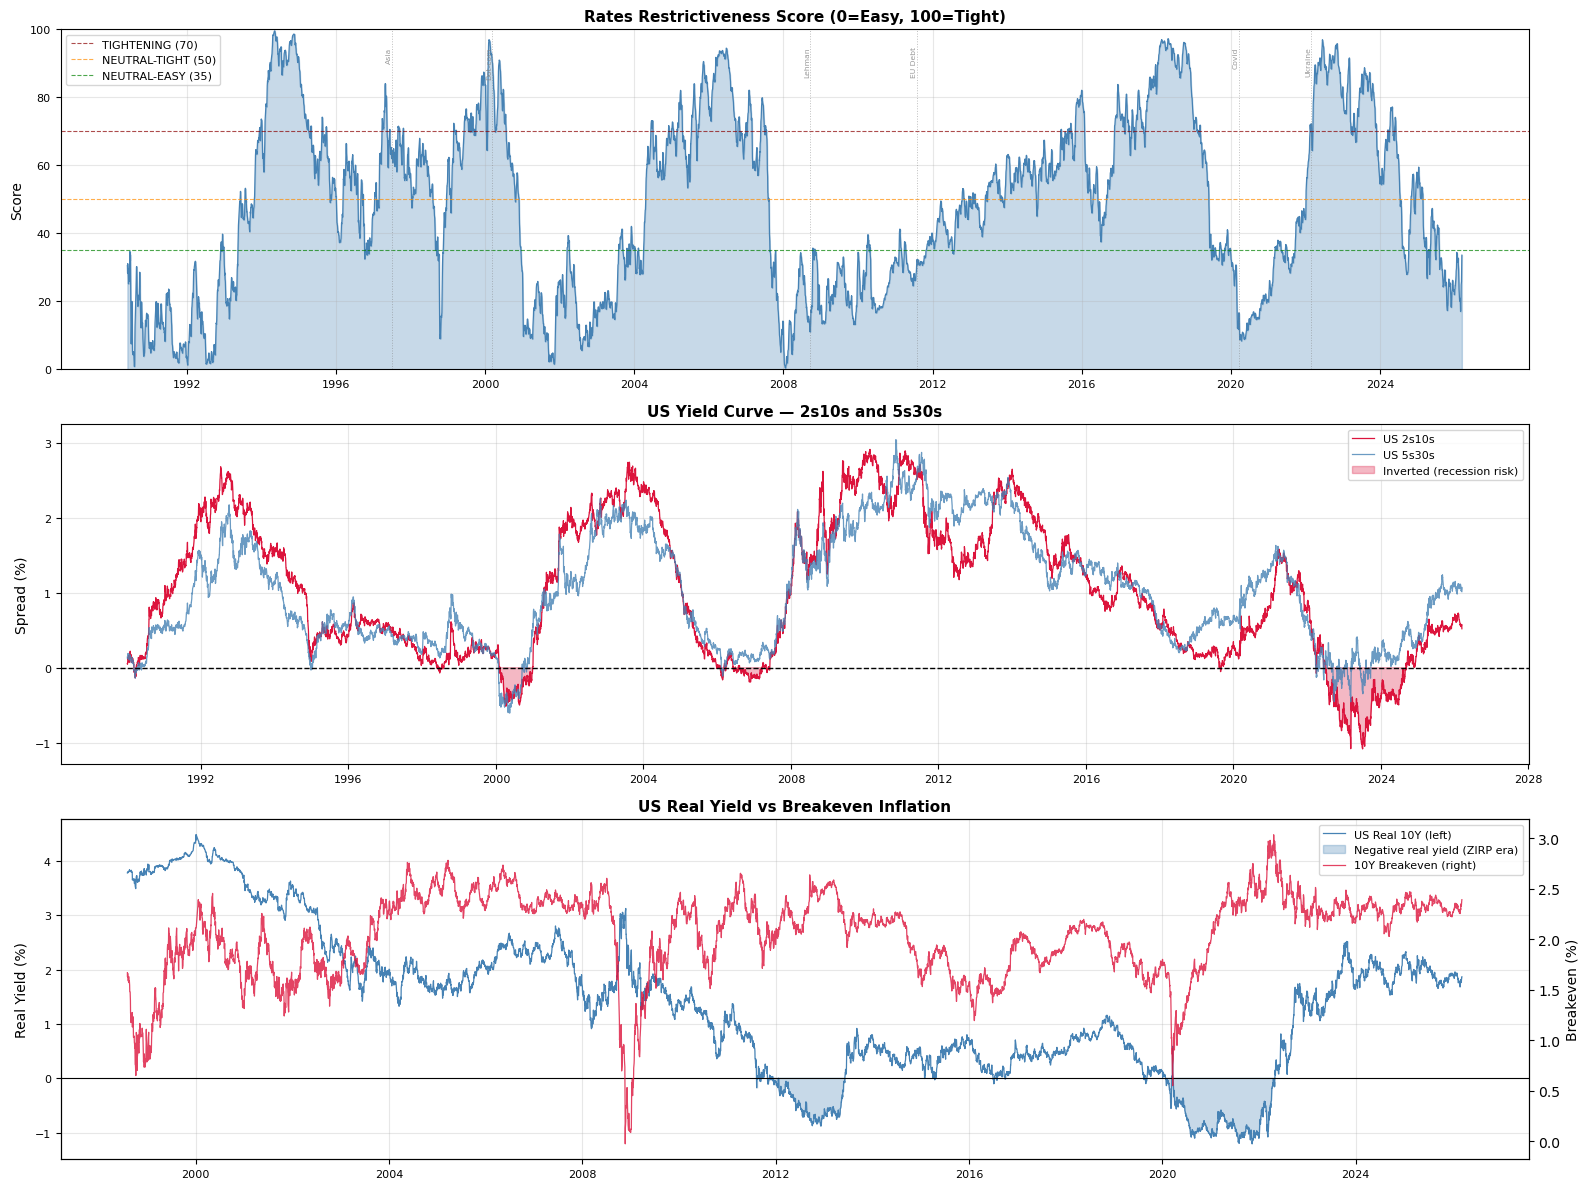


Chart saved: C:\Users\sarda\Desktop\GlobalMacroPulse\outputs\charts\05_branch4_rates_score.png
Branch 4 output saved.


In [2]:
# ── Cell 2: Rates Regime Score and Cycle Analysis ────────────────────────────

def rolling_zscore(series, window=252, min_periods=63):
    m = series.rolling(window, min_periods=min_periods).mean()
    s = series.rolling(window, min_periods=min_periods).std()
    return (series - m) / s

# ── 2A: Z-score every rate and spread ────────────────────────────────────────
# For rates we z-score the LEVEL to understand if they are
# high or low relative to recent history

rate_zscore = pd.DataFrame(index=rates.index)
for ticker in ALL_RATES:
    rate_zscore[ticker] = rolling_zscore(rates[ticker])

# Z-score the spreads
zs_us_2s10s  = rolling_zscore(us_2s10s)
zs_de_2s10s  = rolling_zscore(de_2s10s)
zs_uk_2s10s  = rolling_zscore(uk_2s10s)
zs_jp_2s10s  = rolling_zscore(jp_2s10s)
zs_us_5s30s  = rolling_zscore(us_5s30s)
zs_us_de     = rolling_zscore(us_de_10y)
zs_us_jp     = rolling_zscore(us_jp_10y)
zs_it_de     = rolling_zscore(it_de_10y)
zs_real      = rolling_zscore(us_real_10y)
zs_breakeven = rolling_zscore(prices["USGGBE10 Index"])

print("Rates Z-scores (current readings):")
print("-"*60)
print("  US Yield Curve:")
for ticker, name in US_CURVE.items():
    z = rate_zscore[ticker].dropna().iloc[-1]
    lvl = rates[ticker].dropna().iloc[-1]
    reg = "HIGH" if z > 1 else "LOW" if z < -1 else "NORMAL"
    print(f"    {name:<15} {lvl:>6.2f}%  Z={z:>+5.2f}  [{reg}]")

print("\n  Yield Curve Slopes (2s10s):")
for spread_z, name in [
    (zs_us_2s10s, "US 2s10s"),
    (zs_de_2s10s, "Germany 2s10s"),
    (zs_uk_2s10s, "UK 2s10s"),
    (zs_jp_2s10s, "Japan 2s10s"),
]:
    z   = spread_z.dropna().iloc[-1]
    cur = {"US 2s10s": us_2s10s, "Germany 2s10s": de_2s10s,
           "UK 2s10s": uk_2s10s, "Japan 2s10s": jp_2s10s}[name].dropna().iloc[-1]
    reg = "STEEP" if z > 1 else "FLAT/INVERTED" if z < -1 else "NORMAL"
    print(f"    {name:<18} {cur:>+6.2f}%  Z={z:>+5.2f}  [{reg}]")

print("\n  Real Rates and Inflation:")
z_real = zs_real.dropna().iloc[-1]
z_be   = zs_breakeven.dropna().iloc[-1]
print(f"    US Real 10Y      {us_real_10y.dropna().iloc[-1]:>+6.2f}%  Z={z_real:>+5.2f}")
print(f"    US 10Y Breakeven {prices['USGGBE10 Index'].dropna().iloc[-1]:>+6.2f}%  Z={z_be:>+5.2f}")


# ── 2B: Rates Regime Classifier ──────────────────────────────────────────────
# Classify the current rates environment on two dimensions:
#   1. POLICY direction: Tightening / Neutral / Easing
#   2. CURVE shape: Steep / Normal / Flat / Inverted

# Policy direction: use change in short end (2Y) over past 63 days
us_2y_change_63d = (rates["USGG2YR Index"].dropna().iloc[-1] -
                    rates["USGG2YR Index"].dropna().iloc[-64])

de_2y_change_63d = (rates["GDBR2 Index"].dropna().iloc[-1] -
                    rates["GDBR2 Index"].dropna().iloc[-64])

jp_2y_change_63d = (rates["GJGB2 Index"].dropna().iloc[-1] -
                    rates["GJGB2 Index"].dropna().iloc[-64])

def policy_direction(change_63d):
    if   change_63d >  0.15: return "TIGHTENING"
    elif change_63d < -0.15: return "EASING"
    else:                    return "NEUTRAL"

def curve_shape(spread_2s10s):
    if   spread_2s10s >  0.75: return "STEEP"
    elif spread_2s10s >  0.10: return "NORMAL"
    elif spread_2s10s > -0.10: return "FLAT"
    else:                      return "INVERTED"

us_policy  = policy_direction(us_2y_change_63d)
de_policy  = policy_direction(de_2y_change_63d)
jp_policy  = policy_direction(jp_2y_change_63d)

us_curve_shape = curve_shape(us_2s10s.dropna().iloc[-1])
de_curve_shape = curve_shape(de_2s10s.dropna().iloc[-1])
jp_curve_shape = curve_shape(jp_2s10s.dropna().iloc[-1])

print(f"\nRates Regime Classification:")
print("-"*55)
print(f"  {'Country':<12} {'Policy':<14} {'Curve Shape':<14} {'2Y chg 63d':>10}")
print(f"  {'-'*50}")
for country, policy, shape, chg in [
    ("US",      us_policy, us_curve_shape, us_2y_change_63d),
    ("Germany", de_policy, de_curve_shape, de_2y_change_63d),
    ("Japan",   jp_policy, jp_curve_shape, jp_2y_change_63d),
]:
    print(f"  {country:<12} {policy:<14} {shape:<14} {chg:>+10.2f}%")


# ── 2C: Rates Regime Score (0-100) ───────────────────────────────────────────
# High score = rates environment is RESTRICTIVE / TIGHTENING (bad for equities)
# Low score  = rates environment is EASY / EASING (supportive for equities)
#
# Key inputs:
#   - Real yield level (high real yield = restrictive)
#   - Curve slope (inverted = recession risk = restrictive)
#   - Rate of change of short end (rising = tightening)
#   - Breakeven inflation (high = inflation risk = may force more tightening)

PCTILE_WINDOW = 756

def rolling_pctile(series, window=756, min_periods=126):
    return series.rolling(window, min_periods=min_periods).apply(
        lambda x: pd.Series(x).rank(pct=True).iloc[-1] * 100, raw=False
    )

# Real yield percentile (high real yield = restrictive = high score)
p_real    = rolling_pctile(us_real_10y)

# Curve FLATNESS percentile (flat/inverted = restrictive = high score)
# Invert the 2s10s so that flat=high percentile
p_flat    = rolling_pctile(-us_2s10s)

# Short rate level percentile (high short rate = restrictive)
p_short   = rolling_pctile(rates["USGG2YR Index"])

# Breakeven inflation (high = inflation pressure = restrictive)
p_infl    = rolling_pctile(prices["USGGBE10 Index"])

# Rate of change of 10Y (rising = tightening)
us_10y_roc = rates["USGG10YR Index"].diff(63)   # 63-day change
p_roc     = rolling_pctile(us_10y_roc)

# Weighted rates score
RATES_WEIGHTS = {
    "real_yield":  0.30,
    "curve_flat":  0.25,
    "short_rate":  0.20,
    "inflation":   0.15,
    "roc":         0.10,
}

rates_score  = pd.Series(0.0, index=rates.index)
weight_avail = pd.Series(0.0, index=rates.index)

for series, key in [
    (p_real,  "real_yield"),
    (p_flat,  "curve_flat"),
    (p_short, "short_rate"),
    (p_infl,  "inflation"),
    (p_roc,   "roc"),
]:
    w     = RATES_WEIGHTS[key]
    valid = series.notna()
    rates_score[valid]  += series[valid] * w
    weight_avail[valid] += w

rates_score = rates_score / weight_avail
rates_score = rates_score.rolling(5, min_periods=1).mean()
rates_score.name = "Rates Restrictiveness Score"

def classify_rates_regime(score):
    if   score >= 70: return "TIGHTENING"
    elif score >= 50: return "NEUTRAL-TIGHT"
    elif score >= 35: return "NEUTRAL-EASY"
    else:             return "EASING"

rates_regime = rates_score.apply(classify_rates_regime)

cur_rates   = rates_score.dropna().iloc[-1]
cur_regime  = classify_rates_regime(cur_rates)
all_time_p  = (rates_score.dropna() < cur_rates).sum() / len(rates_score.dropna()) * 100

print(f"\nRates Restrictiveness Score as of {rates_score.dropna().index[-1].date()}:")
print(f"  Score           : {cur_rates:.1f} / 100")
print(f"  Regime          : {cur_regime}")
print(f"  All-time pctile : {all_time_p:.1f}th percentile")
print(f"\nRegime distribution over full history:")
print(rates_regime.value_counts().to_string())


# ── 2D: Plots ─────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(3, 1, figsize=(16, 12))

# Top: Rates Score
ax1 = axes[0]
ax1.fill_between(rates_score.index, rates_score.values, alpha=0.3, color="steelblue")
ax1.plot(rates_score.index, rates_score.values, lw=0.9, color="steelblue")
ax1.axhline(70, color="darkred",   lw=0.8, ls="--", alpha=0.7, label="TIGHTENING (70)")
ax1.axhline(50, color="darkorange",lw=0.8, ls="--", alpha=0.7, label="NEUTRAL-TIGHT (50)")
ax1.axhline(35, color="green",     lw=0.8, ls="--", alpha=0.7, label="NEUTRAL-EASY (35)")
for crisis_date, label in CRISES:
    try:
        ax1.axvline(pd.Timestamp(crisis_date), color="grey", lw=0.7, ls=":", alpha=0.5)
        ax1.text(pd.Timestamp(crisis_date), 95, label, fontsize=5.5,
                 rotation=90, va="top", ha="right", color="grey", alpha=0.8)
    except: pass
ax1.set_title("Rates Restrictiveness Score (0=Easy, 100=Tight)",
              fontsize=11, fontweight="bold")
ax1.set_ylabel("Score")
ax1.legend(fontsize=8, loc="upper left")
ax1.set_ylim(0, 100)
ax1.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
ax1.tick_params(labelsize=8); ax1.grid(alpha=0.3)

# Middle: US 2s10s with recession shading
ax2 = axes[1]
ax2.plot(us_2s10s.dropna().index, us_2s10s.dropna().values,
         lw=0.9, color="crimson", label="US 2s10s")
ax2.plot(us_5s30s.dropna().index, us_5s30s.dropna().values,
         lw=0.9, color="steelblue", label="US 5s30s", alpha=0.8)
ax2.axhline(0, color="black", lw=1.0, ls="--")
ax2.fill_between(us_2s10s.dropna().index, us_2s10s.dropna().values, 0,
                 where=us_2s10s.dropna().values < 0,
                 alpha=0.3, color="crimson", label="Inverted (recession risk)")
ax2.set_title("US Yield Curve — 2s10s and 5s30s",
              fontsize=11, fontweight="bold")
ax2.set_ylabel("Spread (%)")
ax2.legend(fontsize=8)
ax2.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
ax2.tick_params(labelsize=8); ax2.grid(alpha=0.3)

# Bottom: Real yield and breakeven
ax3 = axes[2]
ax3_twin = ax3.twinx()
ax3.plot(us_real_10y.dropna().index, us_real_10y.dropna().values,
         lw=0.9, color="steelblue", label="US Real 10Y (left)")
ax3.axhline(0, color="black", lw=0.8)
ax3.fill_between(us_real_10y.dropna().index, us_real_10y.dropna().values, 0,
                 where=us_real_10y.dropna().values < 0,
                 alpha=0.3, color="steelblue", label="Negative real yield (ZIRP era)")
ax3_twin.plot(prices["USGGBE10 Index"].dropna().index,
              prices["USGGBE10 Index"].dropna().values,
              lw=0.9, color="crimson", alpha=0.8, label="10Y Breakeven (right)")
ax3.set_title("US Real Yield vs Breakeven Inflation",
              fontsize=11, fontweight="bold")
ax3.set_ylabel("Real Yield (%)")
ax3_twin.set_ylabel("Breakeven (%)")
lines1, l1 = ax3.get_legend_handles_labels()
lines2, l2 = ax3_twin.get_legend_handles_labels()
ax3.legend(lines1+lines2, l1+l2, fontsize=8)
ax3.grid(alpha=0.3)
ax3.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
ax3.tick_params(labelsize=8)

plt.tight_layout()
chart_path = os.path.join(cfg.OUT_PATH, "charts", "05_branch4_rates_score.png")
plt.savefig(chart_path, dpi=150, bbox_inches="tight")
plt.show()
print(f"\nChart saved: {chart_path}")

# ── Save Branch 4 output ──────────────────────────────────────────────────────
branch4_output = pd.DataFrame({
    "rates_score":   rates_score,
    "rates_regime":  rates_regime,
    "us_2s10s":      us_2s10s,
    "us_5s30s":      us_5s30s,
    "us_real_10y":   us_real_10y,
    "us_de_10y_diff":us_de_10y,
    "us_jp_10y_diff":us_jp_10y,
    "it_de_10y_diff":it_de_10y,
})
branch4_output.to_csv(
    os.path.join(cfg.PROC_PATH, "regimes", "branch4_rates_output.csv")
)
print("Branch 4 output saved.")

In [3]:
# ── Cell 3: Branch 4 Final Summary ───────────────────────────────────────────
from datetime import timedelta

latest = rates_score.dropna().index[-1]

# Load previous branches
branch1 = pd.read_csv(
    os.path.join(cfg.PROC_PATH, "regimes", "branch1_fear_output.csv"),
    index_col="date", parse_dates=True
)
branch2 = pd.read_csv(
    os.path.join(cfg.PROC_PATH, "regimes", "branch2_credit_output.csv"),
    index_col="date", parse_dates=True
)
branch3 = pd.read_csv(
    os.path.join(cfg.PROC_PATH, "regimes", "branch3_equity_output.csv"),
    index_col="date", parse_dates=True
)

fear_now   = branch1["fear_score"].dropna().iloc[-1]
credit_now = branch2["credit_score"].dropna().iloc[-1]
pred_now   = branch3["pred_score"].dropna().iloc[-1]
rates_now  = rates_score.dropna().iloc[-1]

# Regime streak
cur_regime = classify_rates_regime(rates_now)
streak = 0
for r in reversed(rates_regime.dropna().values):
    if r == cur_regime:
        streak += 1
    else:
        break

# Historical analogues
score_series = rates_score.dropna()
diffs        = (score_series - rates_now).abs().sort_values()
diffs        = diffs[diffs.index < (latest - timedelta(days=90))]

# Key rate levels today
us_2y_now  = rates["USGG2YR Index"].dropna().iloc[-1]
us_10y_now = rates["USGG10YR Index"].dropna().iloc[-1]
us_30y_now = rates["USGG30YR Index"].dropna().iloc[-1]
de_10y_now = rates["GDBR10 Index"].dropna().iloc[-1]
jp_10y_now = rates["GJGB10 Index"].dropna().iloc[-1]
real_now   = us_real_10y.dropna().iloc[-1]
be_now     = prices["USGGBE10 Index"].dropna().iloc[-1]
us2s10s_now = us_2s10s.dropna().iloc[-1]

# Implied rate expectations — is market pricing cuts or hikes?
# Approximated by: if 2Y < Fed funds proxy (use 3M T-bill), market expects cuts
tbill_now  = rates["GB3 Govt"].dropna().iloc[-1] if "GB3 Govt" in rates.columns else prices["GB3 Govt"].dropna().iloc[-1]
rate_expect = "PRICING CUTS" if us_2y_now < tbill_now else "PRICING HIKES"

# Cross-country narrative
us_jp_diff_now = us_jp_10y.dropna().iloc[-1]
us_de_diff_now = us_de_10y.dropna().iloc[-1]

print("=" * 65)
print("   BRANCH 4 — RATES & CURVES REPORT")
print(f"   As of {latest.date()}")
print("=" * 65)

print(f"\n  RATES SCORE     :  {rates_now:.1f} / 100")
print(f"  REGIME          :  {cur_regime}")
print(f"  REGIME STREAK   :  {streak} days")
print(f"  ALL-TIME PCTILE :  {all_time_p:.1f}th percentile")

print(f"\n  ── US Yield Curve ──────────────────────────────────")
print(f"  2Y   : {us_2y_now:.2f}%   10Y  : {us_10y_now:.2f}%")
print(f"  2s10s: {us2s10s_now:>+.2f}%  ({curve_shape(us2s10s_now)})")
print(f"  Real 10Y     : {real_now:>+.2f}%  ({'Restrictive' if real_now > 1.5 else 'Neutral' if real_now > 0 else 'Stimulative'})")
print(f"  Breakeven    : {be_now:.2f}%  ({'Elevated' if be_now > 2.5 else 'Normal'})")
print(f"  Rate market  : {rate_expect} (2Y={us_2y_now:.2f}% vs T-Bill={tbill_now:.2f}%)")

print(f"\n  ── Policy Directions ───────────────────────────────")
for country, chg, policy in [
    ("US",      us_2y_change_63d, us_policy),
    ("Germany", de_2y_change_63d, de_policy),
    ("Japan",   jp_2y_change_63d, jp_policy),
]:
    print(f"  {country:<10} 2Y chg 63d: {chg:>+.2f}%   [{policy}]")

print(f"\n  ── Cross-Country Differentials ─────────────────────")
print(f"  US-Germany 10Y : {us_de_diff_now:>+.2f}%  "
      f"({'USD supportive' if us_de_diff_now > 1.0 else 'EUR supportive'})")
print(f"  US-Japan 10Y   : {us_jp_diff_now:>+.2f}%  "
      f"({'USD supportive' if us_jp_diff_now > 2.0 else 'JPY strengthening pressure'})")
print(f"  Italy-Germany  : {it_de_10y.dropna().iloc[-1]:>+.2f}%  "
      f"({'EU stress' if it_de_10y.dropna().iloc[-1] > 2.0 else 'EU calm'})")

print(f"\n  ── Key Observations ────────────────────────────────")
if us2s10s_now < 0:
    print(f"  ⚠️  US CURVE INVERTED — historical recession warning")
elif us2s10s_now < 0.5:
    print(f"  ⚠️  US CURVE FLAT — re-steepening from inversion")
else:
    print(f"  ✓  US CURVE NORMAL — no immediate recession signal")

if real_now > 2.0:
    print(f"  ⚠️  REAL YIELDS ELEVATED — headwind for equities and gold")
elif real_now > 0:
    print(f"  ~  REAL YIELDS POSITIVE — mildly restrictive")
else:
    print(f"  ✓  REAL YIELDS NEGATIVE — stimulative for risk assets")

if us_jp_diff_now < 2.5:
    print(f"  ⚠️  US-JAPAN DIFF NARROWING — JPY strengthening pressure (BOJ hiking)")
if be_now > 2.3:
    print(f"  ⚠️  BREAKEVEN ELEVATED — inflation expectations above target")

print(f"\n  ── Cross-Branch Context ────────────────────────────")
print(f"  Fear   (B1) : {fear_now:.1f}   ACUTE")
print(f"  Credit (B2) : {credit_now:.1f}   BENIGN")
print(f"  Equity (B3) : {pred_now:.1f}   MODERATE")
print(f"  Rates  (B4) : {rates_now:.1f}   {cur_regime}")
print()
print(f"  Rates are EASING (already priced in) while fear is")
print(f"  ACUTE. Bond market is pricing rate cuts. Equity")
print(f"  market is selling off. This is consistent with")
print(f"  growth slowdown expectations — market wants Fed")
print(f"  to cut but hasn't confirmed it yet.")

print(f"\n  ── Historical Analogues ────────────────────────────")
shown = []
for date, diff in diffs.items():
    if all(abs((date - d).days) > 60 for d in shown):
        fear_then  = branch1["fear_score"].get(date, float("nan"))
        us10y_then = rates["USGG10YR Index"].get(date, float("nan"))
        s10s_then  = us_2s10s.get(date, float("nan"))
        print(f"  {str(date.date())}  Rates={score_series.get(date,0):.1f}  "
              f"Fear={fear_then:.1f}  US10Y={us10y_then:.2f}%  2s10s={s10s_then:>+.2f}%")
        shown.append(date)
    if len(shown) >= 5:
        break

print("\n" + "=" * 65)
print("  Branch 4 complete. Output saved to data/processed/regimes/")
print("=" * 65)

   BRANCH 4 — RATES & CURVES REPORT
   As of 2026-03-13

  RATES SCORE     :  33.6 / 100
  REGIME          :  EASING
  REGIME STREAK   :  163 days
  ALL-TIME PCTILE :  34.0th percentile

  ── US Yield Curve ──────────────────────────────────
  2Y   : 3.74%   10Y  : 4.26%
  2s10s: +0.52%  (NORMAL)
  Real 10Y     : +1.87%  (Restrictive)
  Breakeven    : 2.39%  (Normal)
  Rate market  : PRICING HIKES (2Y=3.74% vs T-Bill=3.69%)

  ── Policy Directions ───────────────────────────────
  US         2Y chg 63d: +0.28%   [TIGHTENING]
  Germany    2Y chg 63d: +0.28%   [TIGHTENING]
  Japan      2Y chg 63d: +0.20%   [TIGHTENING]

  ── Cross-Country Differentials ─────────────────────
  US-Germany 10Y : +1.30%  (USD supportive)
  US-Japan 10Y   : +2.07%  (USD supportive)
  Italy-Germany  : +0.79%  (EU calm)

  ── Key Observations ────────────────────────────────
  ✓  US CURVE NORMAL — no immediate recession signal
  ~  REAL YIELDS POSITIVE — mildly restrictive
  ⚠️  US-JAPAN DIFF NARROWING — JPY st